# Import Required libraries

In [1]:
import os
from typing import List, Dict
import mne
from tqdm import tqdm
tqdm.pandas()

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")


# sklearn packages 
from sklearn.model_selection import train_test_split


In [2]:
def plot_eeg_signal(SubjectID: str, filename: str, label: str):
    # Load CSV
    eda_df = pd.read_csv(f"./data/{SubjectID}/{filename}.csv")
    eda_df.rename(columns={"Unnamed: 0": "Time"}, inplace=True)
    eda_df["Time"] = eda_df["Time"] / 125.0  # Adjust sampling rate
    
    # Extract time & data
    time = eda_df.iloc[:, 0]  # Time column
    channels = eda_df.columns[1:]  # EEG channel names
    data = eda_df.iloc[:, 1:].values  # EEG data

    # Plot
    plt.figure(figsize=(15, 10))
    offset = 200  # vertical spacing between channels
    
    for i, channel in enumerate(channels):
        plt.plot(time, data[:, i] + i * offset, color="black", linewidth=0.8)

    # Replace y-axis ticks with channel names
    yticks = [i * offset for i in range(len(channels))]
    plt.yticks(yticks, channels)

    plt.xlabel("Time (s)")
    plt.ylabel("EEG Channels")
    plt.title(f"EEG Signal for Subject {SubjectID}, Repetition R1, Motor ({label}) - 125Hz Sampling Rate")
    plt.tight_layout()
    plt.show()

# Load the dataset

In [ ]:
eeg_data = pd.read_pickle("../data/processed/eeg_processed.pkl")
eeg_data.reset_index(drop = True, inplace = True)
eeg_data["shape"] = eeg_data["epoch_data"].apply(lambda x : x.shape)
eeg_data = eeg_data[eeg_data["shape"]!=(64, 0)]
eeg_data

,subject,trial,trail_type,epoch_data,label,label_description,shape
0,S001,6,imaginary,"[[8.2e-05, 8.9e-05, 9.7e-05, 9.3e-05, 8.8e-05,...",T2,both_feet,"(64, 656)"
1,S001,6,imaginary,"[[5.3e-05, 5.2e-05, 2.4999999999999998e-05, 1....",T1,both_fist,"(64, 656)"
2,S001,6,imaginary,"[[-1.2e-05, -2.6e-05, -2.7e-05, -3.9e-05, -3.9...",T1,both_fist,"(64, 656)"
3,S001,6,imaginary,"[[3.9999999999999996e-05, 3.2999999999999996e-...",T2,both_feet,"(64, 656)"
4,S001,6,imaginary,"[[9.3e-05, 9.3e-05, 9.6e-05, 9.9e-05, 9.3e-05,...",T1,both_fist,"(64, 656)"
...,...,...,...,...,...,...,...
96,S003,6,imaginary,"[[0.000208, 0.000193, 0.00018199999999999998, ...",T1,both_fist,"(64, 656)"
97,S003,6,imaginary,"[[-5.8e-05, -6.2e-05, -5.2e-05, -3.79999999999...",T2,both_feet,"(64, 655)"
98,S003,6,imaginary,"[[0.000186, 0.00018199999999999998, 0.000168, ...",T2,both_feet,"(64, 655)"
99,S003,6,imaginary,"[[4.2e-05, 5.4e-05, 8.8e-05, 0.000108999999999...",T1,both_fist,"(64, 656)"


In [25]:
index_num = 97
index_num = 97

In [26]:
# Define constants once
CH_NAMES = ['Fc5.','Fc3.','Fc1.','Fcz.','Fc2.','Fc4.','Fc6.','C5..','C3..','C1..','Cz..','C2..','C4..','C6..',
            'Cp5.','Cp3.','Cp1.','Cpz.','Cp2.','Cp4.','Cp6.','Fp1.','Fpz.','Fp2.','Af7.','Af3.','Afz.','Af4.',
            'Af8.','F7..','F5..','F3..','F1..','Fz..','F2..','F4..','F6..','F8..','Ft7.','Ft8.','T7..','T8..',
            'T9..','T10.','Tp7.','Tp8.','P7..','P5..','P3..','P1..','Pz..','P2..','P4..','P6..','P8..','Po7.',
            'Po3.','Poz.','Po4.','Po8.','O1..','Oz..','O2..','Iz..']
SFREQ = 160
CH_TYPES = ["eeg"] * 64


# UDFs

In [27]:
def plot_eeg_signal(eeg_data, fs, label):
    n_samples = eeg_data.shape[1]
    time = np.arange(n_samples) / fs

    # Plot EEG signals
    plt.figure(figsize=(15, 6))
    for i in range(eeg_data.shape[0]):
        plt.plot(time, eeg_data[i], label=f'Channel {i+1}')  # offset for visibility

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"EEG Signal Plot - {label}")
    plt.grid(True)
    plt.show()

# EEG PreProcessing

#### Step 1: Normalization

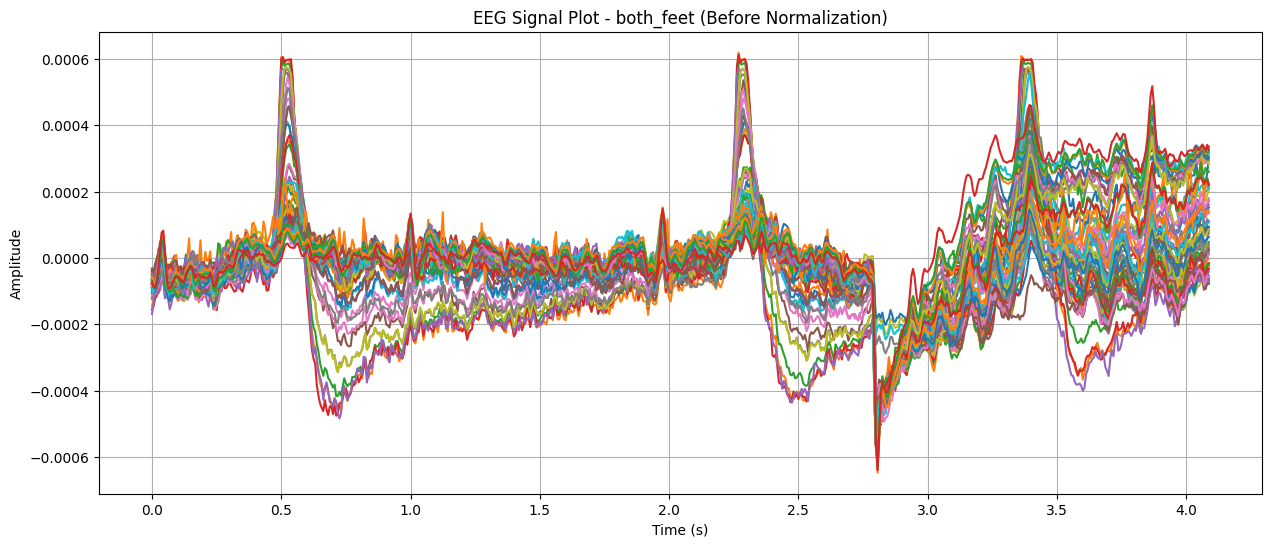

In [28]:
plot_eeg_signal(eeg_data= eeg_data["epoch_data"][index_num], fs = 160, label = eeg_data["label_description"][index_num]+" "+"(Before Normalization)")


In [8]:
def zscore_normalization(eeg_data:np.array) -> np.array:
    """
        EEG Data : numpy array of shape (n_channels, n_samples)
    """

    mean = np.mean(eeg_data, axis = 1, keepdims= True)
    std = np.std(eeg_data, axis = 1, keepdims=True)
    return (eeg_data - mean)/std


eeg_data["epoch_data_normalized"] = eeg_data["epoch_data"].apply(zscore_normalization)

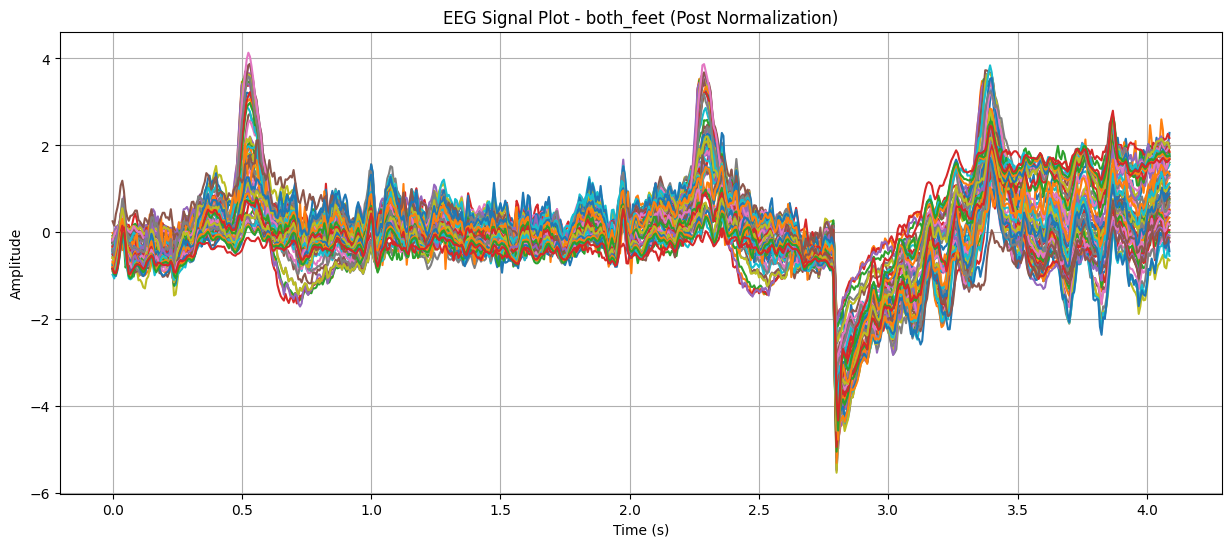

In [29]:
plot_eeg_signal(eeg_data= eeg_data["epoch_data_normalized"][index_num], fs = 160, label = eeg_data["label_description"][index_num]+" "+"(Post Normalization)")

#### 2. Band-Pass Filtering - (0.5 - 50 Hz range) 

In [10]:
def band_pass_filter(l_freq: float, h_freq: float, eeg_data: np.ndarray) -> np.ndarray:
    """
    Apply band-pass filter using MNE's filter_data.
    eeg_data: shape (n_channels, n_times)
    """
    return mne.filter.filter_data(
        data=eeg_data,
        sfreq=SFREQ,
        l_freq=l_freq,
        h_freq=h_freq,
        verbose=False
    )
eeg_data["epoch_data_bandpass"] = eeg_data["epoch_data_normalized"].apply(lambda x : band_pass_filter(l_freq=0.5, 
                                                                                                    h_freq=50, 
                                                                                                    eeg_data= x))

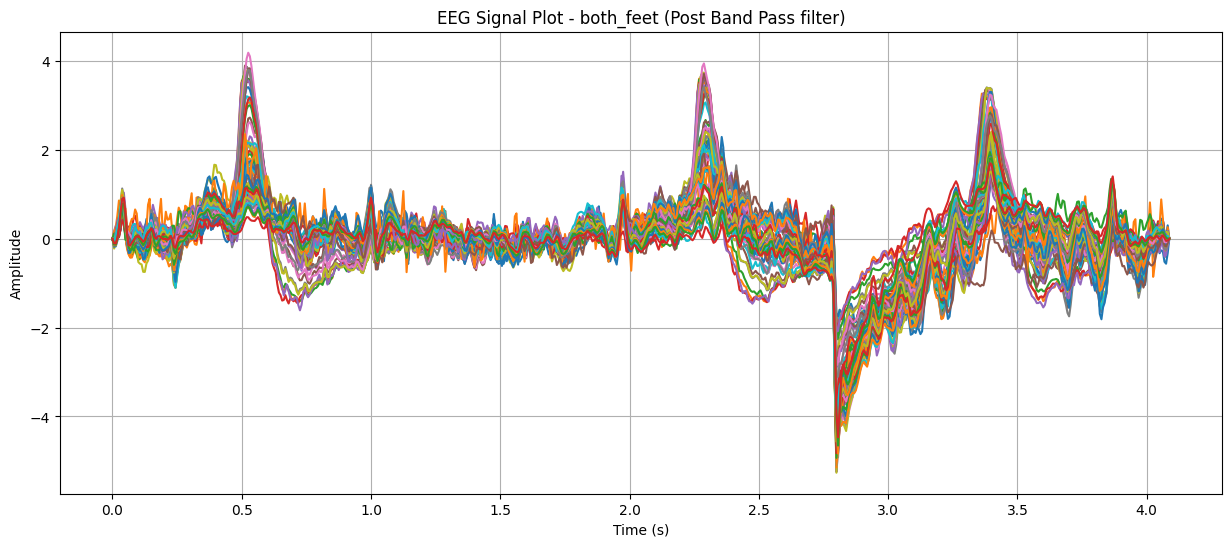

In [30]:
plot_eeg_signal(eeg_data= eeg_data["epoch_data_bandpass"][index_num], 
                fs = 160, 
                label = eeg_data["label_description"][index_num]+" "+"(Post Band Pass filter)")


#### Step 3 : ICA (Independent Component Analysis)

In [19]:
INFO = mne.create_info(ch_names=CH_NAMES, sfreq=SFREQ, ch_types=CH_TYPES)

def run_ica(eeg_data: np.ndarray, n_components: int = 64, method: str = "fastica", random_state: int = 97) -> np.ndarray:
    """
    Run ICA on EEG data (single epoch) and return artifact-cleaned EEG.
    
    Parameters:
    -----------
    eeg_data : np.ndarray
        EEG data of shape (n_channels, n_times).
    n_components : int
        Number of ICA components to estimate.
    method : str
        ICA method ('fastica', 'infomax', 'picard').
    random_state : int
        Reproducibility seed.
    
    Returns:
    --------
    np.ndarray : Cleaned EEG data of shape (n_channels, n_times).
    """
    # Create RawArray for MNE ICA
    raw = mne.io.RawArray(data=eeg_data, info=INFO, verbose=False)

    # Initialize ICA
    ica = mne.preprocessing.ICA(
        n_components=n_components,
        method=method,
        random_state=random_state,
        max_iter="auto"
    )
    
    # Fit ICA
    ica.fit(raw)

    #Automatically detect EOG artifacts if EOG channel exists
    eog_inds, _ = ica.find_bads_eog(raw, ch_name = ["Fp1.", 
                                           "Fpz.", 
                                           "Fp2."])
    ica.exclude = eog_inds

    # Apply ICA
    raw_clean = raw.copy()
    ica.apply(raw_clean)

    return raw_clean.get_data(), eog_inds


In [ ]:
def run_ica_safe(eeg_data_ICA: np.ndarray, n_components: int = 20):
    try:
        # Fill NaNs first
        eeg_data_ICA = np.nan_to_num(eeg_data_ICA, 0.0)
        # Run ICA (reuse your previous function)
        return run_ica(eeg_data_ICA, n_components=n_components)
    except Exception as e:
        print(f"ICA failed for an epoch: {e}")
        # Return original EEG data if ICA fails
        return "Error", "Error"

# Apply with progress bar
eeg_data_preprocessed, eog_inds = [], []
for eeg_data_ICA in tqdm(eeg_data["epoch_data_bandpass"], desc="ICA robust"):
    preprocessed_eeg_data, inds = run_ica_safe(eeg_data_ICA)
    eeg_data_preprocessed.append(preprocessed_eeg_data)
    eog_inds.append(inds)    


ICA robust:   0%|          | 0/101 [00:00<?, ?it/s]

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 0.1s.
Using EOG channels: Fp1., Fpz., Fp2.
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1600 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth

ICA robust:   1%|          | 1/101 [00:00<00:16,  5.96it/s]

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 0.2s.
Using EOG channels: Fp1., Fpz., Fp2.
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1600 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth

ICA robust:   2%|▏         | 2/101 [00:00<00:22,  4.37it/s]

...

ICA robust:  96%|█████████▌| 97/101 [00:20<00:00,  7.17it/s]

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 0.0s.
Using EOG channels: Fp1., Fpz., Fp2.
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1600 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth

ICA robust:  98%|█████████▊| 99/101 [00:20<00:00,  7.71it/s]

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 0.0s.
Using EOG channels: Fp1., Fpz., Fp2.
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1600 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth

ICA robust: 100%|██████████| 101/101 [00:20<00:00,  4.87it/s]


In [31]:
eeg_data["epoch_data_ICA"] = eeg_data_preprocessed
eeg_data["epoch_data_ICA_inds"] = eog_inds

In [32]:
eeg_data

,subject,trial,trail_type,epoch_data,label,label_description,shape,epoch_data_normalized,epoch_data_bandpass,epoch_data_ICA,epoch_data_ICA_inds
0,S001,6,imaginary,"[[8.2e-05, 8.9e-05, 9.7e-05, 9.3e-05, 8.8e-05,...",T2,both_feet,"(64, 656)","[[1.987791713489556, 2.1413237395999967, 2.316...","[[-3.5518463170625125e-16, 0.21048354619493068...","[[0.0, 0.21048354619493126, 0.2986583119139636...",[]
1,S001,6,imaginary,"[[5.3e-05, 5.2e-05, 2.4999999999999998e-05, 1....",T1,both_fist,"(64, 656)","[[0.6086756361986259, 0.5973414735103207, 0.29...","[[1.5785983631388945e-16, -0.04453340587842366...","[[4.326586822038409e-16, -0.04453340587842791,...",[]
2,S001,6,imaginary,"[[-1.2e-05, -2.6e-05, -2.7e-05, -3.9e-05, -3.9...",T1,both_fist,"(64, 656)","[[-0.5890508792650638, -0.8071017972485521, -0...","[[-4.211041237933699e-16, -0.1837621958169452,...","[[0.1443627650117816, -0.11784160118297056, -0...",[0]
3,S001,6,imaginary,"[[3.9999999999999996e-05, 3.2999999999999996e-...",T2,both_feet,"(64, 656)","[[0.8752090876209437, 0.7471106580182353, 0.87...","[[-3.946495907847236e-16, -0.08058054207404561...","[[-5.683271816705565e-16, -0.0805805420740457,...",[]
4,S001,6,imaginary,"[[9.3e-05, 9.3e-05, 9.6e-05, 9.9e-05, 9.3e-05,...",T1,both_fist,"(64, 656)","[[-0.07961769787496903, -0.07961769787496903, ...","[[2.6020852139652106e-17, -0.00030306978408156...","[[-2.6412250984725782e-17, -0.0003030697840818...",[]
...,...,...,...,...,...,...,...,...,...,...,...
96,S003,6,imaginary,"[[0.000208, 0.000193, 0.00018199999999999998, ...",T1,both_fist,"(64, 656)","[[3.4450852066076725, 3.205684361753649, 3.030...","[[-1.2105117255800657e-15, -0.2513878190258361...","[[-2.712833737380668e-16, -0.2513878190258335,...",[]
97,S003,6,imaginary,"[[-5.8e-05, -6.2e-05, -5.2e-05, -3.79999999999...",T2,both_feet,"(64, 655)","[[-0.39489795642065634, -0.42900934891751175, ...","[[-4.215378046623641e-16, -0.02339634305477155...","[[0.004862442262990897, -0.0053509178949595355...",[1]
98,S003,6,imaginary,"[[0.000186, 0.00018199999999999998, 0.000168, ...",T2,both_feet,"(64, 655)","[[2.722028757848655, 2.6607144247024856, 2.446...","[[5.126107871511465e-16, -0.007219788469787648...","[[-0.2693920199260885, -0.07676111911558775, -...",[0]
99,S003,6,imaginary,"[[4.2e-05, 5.4e-05, 8.8e-05, 0.000108999999999...",T1,both_fist,"(64, 656)","[[0.5637123038669324, 0.7106264987366722, 1.12...","[[1.448494102440634e-16, 0.18365847903626248, ...","[[2.9015182879751773e-16, 0.18365847903626212,...",[]


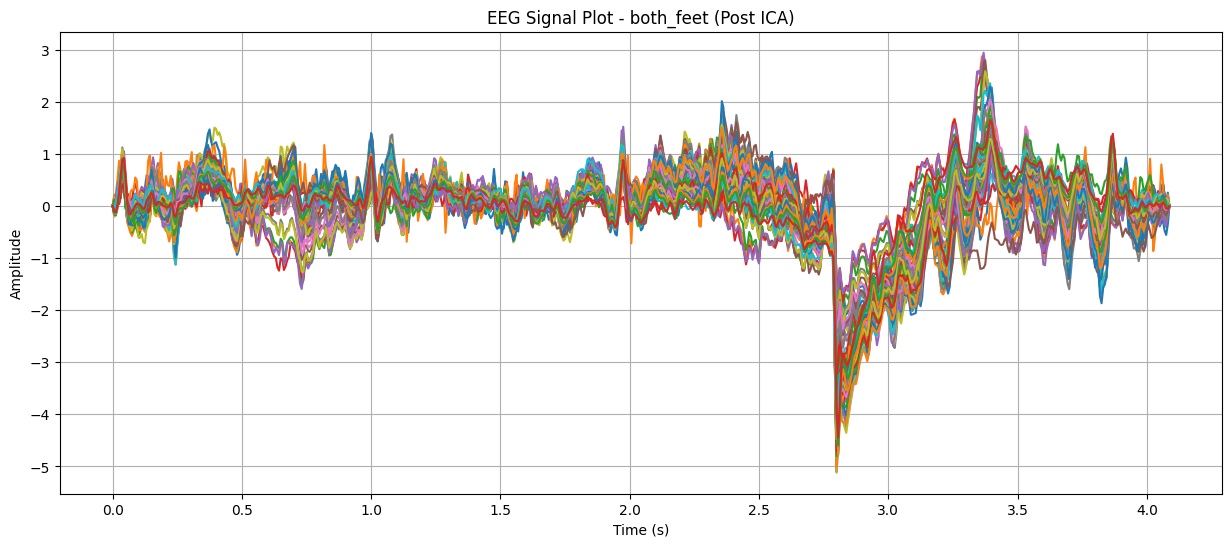

In [33]:
plot_eeg_signal(eeg_data= eeg_data["epoch_data_ICA"][index_num], 
                fs = 160, 
                label = eeg_data["label_description"][index_num]+" "+"(Post ICA)")


# Final Preprocessed DataFrame

In [ ]:
data = pd.read_pickle("../data/processed/eeg_processed_X_train.pkl")

# Creating a column just to identify the records that are bad
data["factor"]=data["epoch_data_ICA"].apply(lambda  x : "str" if type(x) == str else "not_str")
data = data[~(data["factor"] == "str")]

# drop the column that was created 
data.drop("factor", axis = 1, inplace = True)

In [ ]:
data.to_pickle("../data/processed/eeg_processed_X_train.pkl")